## import and function def

In [118]:
import pandas as pd
from pathlib import Path
import re
import numpy as np

debugging = True

# OGT parsing 
# for ogt text entries, decide on mean ogt and ogt range 
parse_ogt_bounds_text_dict = {
    "moderate to warm": (55, 20),
    "mesophile": (50, 10),
}
def parse_ogt_bounds(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan])
    
    key = str(value).strip().lower()
    if key in parse_ogt_bounds_text_dict:
        lower, upper = parse_ogt_bounds_text_dict[key]
        return pd.Series([lower, upper])
    
    parts = re.split(r'[-/]', str(value))
    nums = [float(p.strip()) for p in parts if p.strip()]
    
    if not nums:
        return pd.Series([np.nan, np.nan])
    
    return pd.Series([np.mean([max(nums), min(nums)]), max(nums) - min(nums)])

# number of cys residues parsing
parse_cys_residues_text_dict = {
    "yes": 4,
    "no": 0,
}
def parse_rubredoxin_and_cys_residues(value):
    print(f"value: {value}") if debugging else None
    if pd.isna(value):
        print("value is NaN") if debugging else None
        return np.nan
    
    key = str(value).strip().lower()
    if key in parse_cys_residues_text_dict:
        num = parse_cys_residues_text_dict[key]
        print(f"num: {num}") if debugging else None
        return num
    
    match = re.search(r'(\d+(\.\d+)?)', str(value))
    if match:
        print(f"match: {match.group(1)}") if debugging else None
        return float(match.group(1))
    return np.nan
    

# Data Handling

## read file

In [48]:
file_path = Path("All Homologs.xlsx")  # Replace with your actual file path
print("Found file:", file_path)
sheets = pd.read_excel(file_path, sheet_name=None, engine="openpyxl", header=1)  # Read all sheets into a dictionary
for i, key in enumerate(sheets.keys()):
    print(f"Sheet {i}: {key}, {sheets[key].shape[0]} x {sheets[key].shape[1]}")
# for name, df in sheets.items():
#     print(name, list(df.columns))
print_sample = False
if print_sample:
    print("________________________________________________\nprinting first 5 rows of each sheet...")
    for i, key in enumerate(sheets.keys()):
        print(f"Sheet {i}: {key}")
        print(sheets[key].head())
        print("________________________________________________\n")


Found file: All Homologs.xlsx
Sheet 0: Sheet1, 12 x 12
Sheet 1: Earliest-combine(16), 18 x 11
Sheet 2: Ear-Asgard(37), 41 x 11
Sheet 3: Ear-Bathy(72), 70 x 11
Sheet 4: Mid1-diapherotrites(98), 98 x 11
Sheet 5: Mid1-Mo(292), 297 x 11
Sheet 6: Mid2-Hadesarchaea-between Mo&Mu, 34 x 11
Sheet 7: Mid2-Aenigmarchaeota-after-Hade, 52 x 11
Sheet 8: Mid2-Mu, 110 x 11
Sheet 9: Last-small-pre-evolve, 14 x 11
Sheet 10: Last-bacterial, 185 x 11
Sheet 11: Last-archaeal (237), 0 x 11


## pick data sheet

In [ ]:
target_sheet = "Mid2-Hadesarchaea-between Mo&Mu"  # paste in the sheet to look at here
target_df = sheets[target_sheet]

## get OGT values

In [72]:
debugging = False
if debugging: 
    print("sample values at start of pruning:")
    print(target_df["host OGT"])
    print()

# find entries that don't match a clean number/range pattern
pattern = r'^\s*\d+(\.\d+)?(\s*[-/]\s*\d+(\.\d+)?)*\s*$'
mask = target_df["host OGT"].notna() & ~target_df["host OGT"].astype(str).str.match(pattern)
non_numeric_values = target_df.loc[mask, "host OGT"].unique()
print(f"Ensure that the following entries are added to the parse_ogt_bounds text dictionary:\n{non_numeric_values}\n")

# parse host OGT column into lower and upper bounds 
try:
    target_df[["host_ogt_mean", "host_ogt_range"]] = target_df["host OGT"].apply(parse_ogt_bounds)
except Exception as e:
    print("Error. Add non-numeric host OGT values to parse_ogt_bounds text dictionary and rerun.")
print("Successfully parsed host OGT values into lower and upper bounds.")
if debugging:
    print(target_df[["host OGT", "host_ogt_mean", "host_ogt_range"]])

Ensure that the following entries are added to the parse_ogt_bounds text dictionary:
['moderate to warm']

Successfully parsed host OGT values into lower and upper bounds.


## get # cys residues

In [124]:
debugging = False
if debugging: 
    print("sample values at start of pruning:")
    print(target_df["rubredoxin"], target_df["#Cys residue"])
    print()

# parse data input in excel sheet, both rubredoxin and #Cys residue columns, into numeric values
try:
    rub_temp = target_df["rubredoxin"].apply(parse_rubredoxin_and_cys_residues)
    cys_temp = target_df["#Cys residue"].apply(parse_rubredoxin_and_cys_residues)
except Exception as e:
    print("Error. Add non-numeric rubredoxin or #Cys residue values to parse_rubredoxin_and_cys_residues function and rerun.")
# note if data is missing for that line 
target_df["missing_cys_info"] = rub_temp.isna() & cys_temp.isna()
rub_cys_conflict = rub_temp.notna() & cys_temp.notna() & (rub_temp != cys_temp)
# check if there are conflicting values between rubredoxin and #Cys residue columns
print("Entries with conflicting rubredoxin and #Cys residue values:")
print(target_df.loc[rub_cys_conflict, ["rubredoxin", "#Cys residue"]]) if rub_cys_conflict.any() else print("No conflicts found.")
target_df.loc[rub_cys_conflict, ["rubredoxin", "#Cys residue"]]
# combine the two columns into a single column, prioritizing rubredoxin values if present, otherwise using #Cys residue values
target_df["cys_res_in_target_region"] = rub_temp.combine_first(cys_temp).fillna(0)

if debugging:
    print("sample values after parsing:")
    print(target_df["cys_res_in_target_region"])
    print()

Entries with conflicting rubredoxin and #Cys residue values:
No conflicts found.


# Plot data

## import

In [50]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels

## set plot title, legend, colors

In [61]:
plot_title = f"Host OGT vs # cys residues in __ domain\n{target_sheet}"

fig_size = [10, 6]

## plot

Text(0.5, 1.0, 'Host OGT vs # cys residues in __ domain\nMid2-Hadesarchaea-between Mo&Mu')

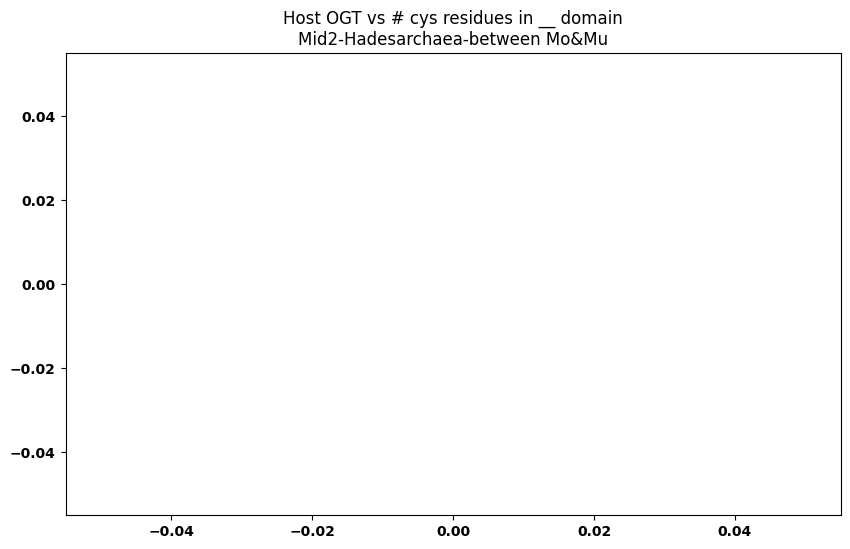

In [62]:
fig, ax = plt.subplots(figsize=(fig_size[0], fig_size[1]))

ax.plot(target_df["#Cys residue"], 
        target_df["host_ogt_mean"], 
        'o', 
        color='blue', 
        alpha=0.7, 
        label='Host OGT Mean')

ax.set_title(plot_title)